In [1]:
import urllib.request
import os

# We will download a NetCDF file from the French IFREMER Argo server
url = "https://data-argo.ifremer.fr/dac/coriolis/6901814/6901814_prof.nc"
file_path = "../data/6901814_prof.nc"

# This checks if you already downloaded it, and if not, downloads it to your data folder
if not os.path.exists(file_path):
    print("Downloading Argo data...")
    urllib.request.urlretrieve(url, file_path)
    print("Download complete! File saved to your 'data' folder.")
else:
    print("Data already exists in your folder.")
    

Download complete! File saved to your 'data' folder.


In [3]:
import xarray as xr
import numpy as np

# Open the dataset
ds = xr.open_dataset(file_path)

# Display the dataset summary
ds

<xarray.Dataset> Size: 2MB
Dimensions:                       (N_PROF: 238, N_PARAM: 3, N_LEVELS: 99,
                                   N_CALIB: 1, N_HISTORY: 0)
Dimensions without coordinates: N_PROF, N_PARAM, N_LEVELS, N_CALIB, N_HISTORY
Data variables: (12/64)
    DATA_TYPE                     object 8B ...
    FORMAT_VERSION                object 8B ...
    HANDBOOK_VERSION              object 8B ...
    REFERENCE_DATE_TIME           object 8B ...
    DATE_CREATION                 object 8B ...
    DATE_UPDATE                   object 8B ...
    ...                            ...
    HISTORY_ACTION                (N_HISTORY, N_PROF) object 0B ...
    HISTORY_PARAMETER             (N_HISTORY, N_PROF) object 0B ...
    HISTORY_START_PRES            (N_HISTORY, N_PROF) float32 0B ...
    HISTORY_STOP_PRES             (N_HISTORY, N_PROF) float32 0B ...
    HISTORY_PREVIOUS_VALUE        (N_HISTORY, N_PROF) float32 0B ...
    HISTORY_QCTEST                (N_HISTORY, N_PROF) object 0B ...
Attributes:
    title:                Argo float vertical profile
    institution:          FR GDAC
    source:               Argo float
    history:              2021-03-09T17:50:16Z creation
    references:           http://www.argodatamgt.org/Documentation
    user_manual_version:  3.1
    Conventions:          Argo-3.1 CF-1.6
    featureType:          trajectoryProfile

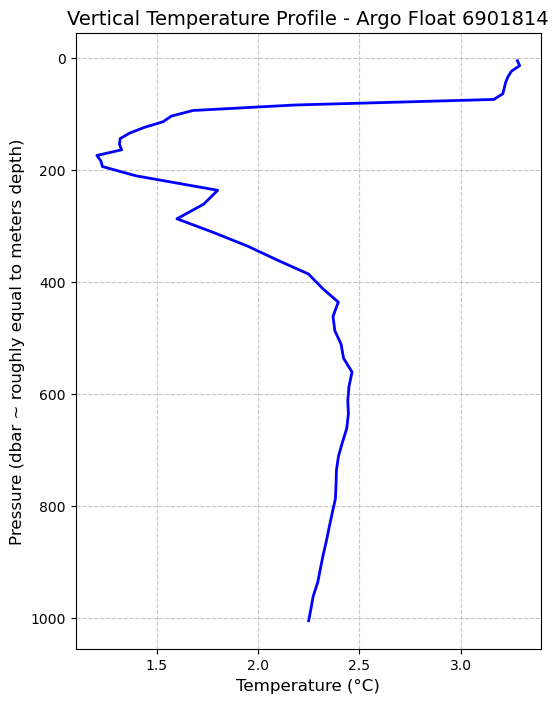

In [5]:
import matplotlib.pyplot as plt

# The float makes many dives. Let's select the very first dive (Profile 0)
profile = ds.isel(N_PROF=0)

# Create the plot
plt.figure(figsize=(6, 8))
plt.plot(profile.TEMP, profile.PRES, color='blue', linewidth=2)

# Oceanographers always invert the Y-axis because depth goes DOWN
plt.gca().invert_yaxis()

# Add labels and a title
plt.xlabel("Temperature (°C)", fontsize=12)
plt.ylabel("Pressure (dbar ~ roughly equal to meters depth)", fontsize=12)
plt.title("Vertical Temperature Profile - Argo Float 6901814", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)

# Save the figure to your figures folder
plt.savefig("../figures/temperature_profile.png", dpi=300, bbox_inches='tight')

plt.show()